#Step 2: Lifecycle and Funnel Analysis

I am going to analyze the lifecycle funnel to understand how contacts progress through each stage, including conversion rates and time to advance. This will help identify bottlenecks and opportunities to improve activation and pipeline growth.

###Summary

After reviewing lifecycle distribution, stage-by-stage conversion, and time-to-stage metrics, three key areas of opportunity were identified:
- A large portion of contacts remain in the Lead stage (~37%), suggesting potential friction in early-stage activation or unclear qualification criteria.
- Disqualification rates (~7%) indicate a potential opportunity to improve lead quality and targeting.
- Opportunity to Customer represents the primary bottleneck in the funnel, combining the lowest conversion rate (~29%) with the longest time-to-stage (26 days).

Segmentation analysis further highlighted differences in performance across role categories and acquisition channels:

- End-to-end conversion by job title category is relatively consistent across Operations, Executive, Energy, Sales/Marketing, and Legal roles. However, Finance and RevOps lag slightly, suggesting these roles may be less directly involved in purchasing decisions or require different messaging.
- By lead source, Outbound and Partner generate the highest-performing leads, while Referral, Organic, Event, and Paid Search show mid-tier performance. Content and Webinar leads have the lowest end-to-end conversion, driven primarily by weaker late-stage performance.

Overall, these findings suggest that improving late-stage deal execution and refining targeting for lower-performing segments represent the highest-impact opportunities to increase overall conversion.

In [0]:
%python
import matplotlib.pyplot as plt

###Current Lifecycle Distribution

In [0]:
select
  lifecycle_stage,
  count(*) as total_contacts,
  round(count(*) * 100.0 / sum(count(*)) over (), 2) as pct_of_total
from crm_clean_contacts
group by lifecycle_stage
order by case lifecycle_stage
  when 'Subscriber' then 1
  when 'Lead' then 2
  when 'MQL' then 3
  when 'SQL' then 4
  when 'Opportunity' then 5
  when 'Customer' then 6
  when 'Disqualified' then 7
  else 8
end

lifecycle_stage,total_contacts,pct_of_total
Subscriber,977,15.03
Lead,2403,36.97
MQL,1292,19.88
SQL,668,10.28
Opportunity,482,7.42
Customer,199,3.06
Disqualified,479,7.37


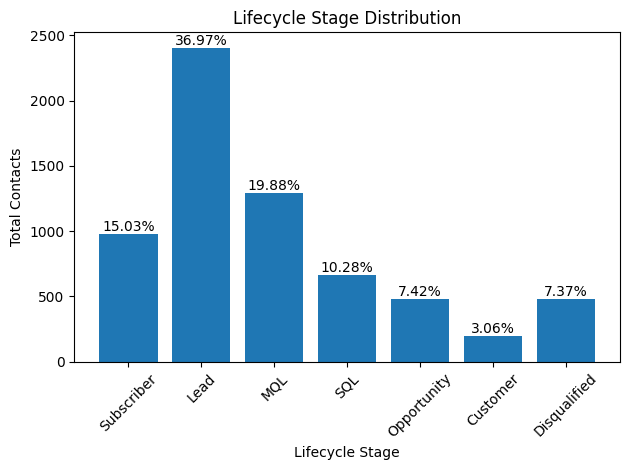

In [0]:
%python
df = spark.sql("""
select
  lifecycle_stage,
  count(*) as total_contacts,
  round(count(*) * 100.0 / sum(count(*)) over (), 2) as pct_of_total
from crm_clean_contacts
group by lifecycle_stage
order by case lifecycle_stage
  when 'Subscriber' then 1
  when 'Lead' then 2
  when 'MQL' then 3
  when 'SQL' then 4
  when 'Opportunity' then 5
  when 'Customer' then 6
  when 'Disqualified' then 7
  else 8
end
""").toPandas()

plt.figure()
plt.bar(df["lifecycle_stage"], df["total_contacts"])

plt.xticks(rotation=45)
plt.xlabel("Lifecycle Stage")
plt.ylabel("Total Contacts")
plt.title("Lifecycle Stage Distribution")

for i, row in df.iterrows():
    plt.text(i, row["total_contacts"], f"{row['pct_of_total']}%", ha='center', va='bottom')

plt.tight_layout()

- A large proportion of contacts remain in the Lead stage (~37%), indicating potential friction in early-stage activation or qualification.
- Mid-funnel progression appears relatively consistent, with gradual drop-offs between MQL, SQL, and Opportunity stages.
- The low Customer conversion rate (~3%) suggests potential inefficiencies in later-stage conversion or a top-heavy funnel composition.
- Disqualification rates (~7%) are moderate but may indicate opportunities to improve targeting or lead quality.

###Conversion Funnel

In [0]:
with funnel_counts as (
  select
    count(*) as total_contacts,

    sum(case when became_lead_at is not null then 1 else 0 end) as leads,
    sum(case when became_mql_at is not null then 1 else 0 end) as mqls,
    sum(case when became_sql_at is not null then 1 else 0 end) as sqls,
    sum(case when became_opportunity_at is not null then 1 else 0 end) as opportunities,
    sum(case when became_customer_at is not null then 1 else 0 end) as customers

  from crm_clean_contacts
)

select
  'Lead to MQL' as funnel_step,
  leads as starting_count,
  mqls as converted_count,
  round(mqls * 100.0 / leads, 2) as conversion_rate
from funnel_counts

union all

select
  'MQL to SQL' as funnel_step,
  mqls as starting_count,
  sqls as converted_count,
  round(sqls * 100.0 / mqls, 2) as conversion_rate
from funnel_counts

union all

select
  'SQL to Opportunity' as funnel_step,
  sqls as starting_count,
  opportunities as converted_count,
  round(opportunities * 100.0 / sqls, 2) as conversion_rate
from funnel_counts

union all

select
  'Opportunity to Customer' as funnel_step,
  opportunities as starting_count,
  customers as converted_count,
  round(customers * 100.0 / opportunities, 2) as conversion_rate
from funnel_counts

funnel_step,starting_count,converted_count,conversion_rate
Lead to MQL,5523,2687,48.65
MQL to SQL,2687,1333,49.61
SQL to Opportunity,1333,681,51.09
Opportunity to Customer,681,199,29.22


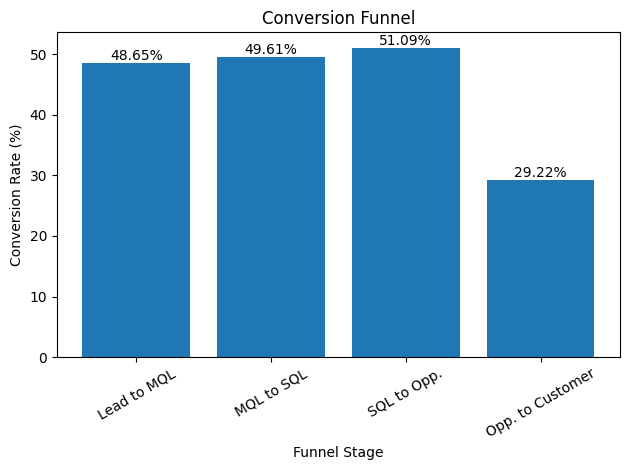

In [0]:
%python
df = spark.sql("""
with funnel_counts as (
  select
    sum(case when became_lead_at is not null then 1 else 0 end) as leads,
    sum(case when became_mql_at is not null then 1 else 0 end) as mqls,
    sum(case when became_sql_at is not null then 1 else 0 end) as sqls,
    sum(case when became_opportunity_at is not null then 1 else 0 end) as opportunities,
    sum(case when became_customer_at is not null then 1 else 0 end) as customers
  from crm_clean_contacts
)

select 'Lead to MQL' as stage, leads as start, mqls as converted, round(mqls * 100.0 / leads, 2) as conversion_rate from funnel_counts
union all
select 'MQL to SQL', mqls, sqls, round(sqls * 100.0 / mqls, 2) from funnel_counts
union all
select 'SQL to Opp.', sqls, opportunities, round(opportunities * 100.0 / sqls, 2) from funnel_counts
union all
select 'Opp. to Customer', opportunities, customers, round(customers * 100.0 / opportunities, 2) from funnel_counts
""").toPandas()

import matplotlib.pyplot as plt

plt.figure()
plt.bar(df["stage"], df["conversion_rate"])

plt.xticks(rotation=30)
plt.xlabel("Funnel Stage")
plt.ylabel("Conversion Rate (%)")
plt.title("Conversion Funnel")

for i, row in df.iterrows():
    plt.text(i, row["conversion_rate"], f"{row['conversion_rate']}%", ha='center', va='bottom')

plt.tight_layout()

###Time-to-Stage

In [0]:
with stage_times as (
  select
    datediff(became_mql_at, became_lead_at) as lead_to_mql,
    datediff(became_sql_at, became_mql_at) as mql_to_sql,
    datediff(became_opportunity_at, became_sql_at) as sql_to_opportunity,
    datediff(became_customer_at, became_opportunity_at) as opportunity_to_customer
  from crm_clean_contacts
)

select
  percentile_approx(lead_to_mql, 0.5) as median_lead_to_mql_days,
  percentile_approx(mql_to_sql, 0.5) as median_mql_to_sql_days,
  percentile_approx(sql_to_opportunity, 0.5) as median_sql_to_opportunity_days,
  percentile_approx(opportunity_to_customer, 0.5) as median_opportunity_to_customer_days
from stage_times

median_lead_to_mql_days,median_mql_to_sql_days,median_sql_to_opportunity_days,median_opportunity_to_customer_days
7,6,11,26


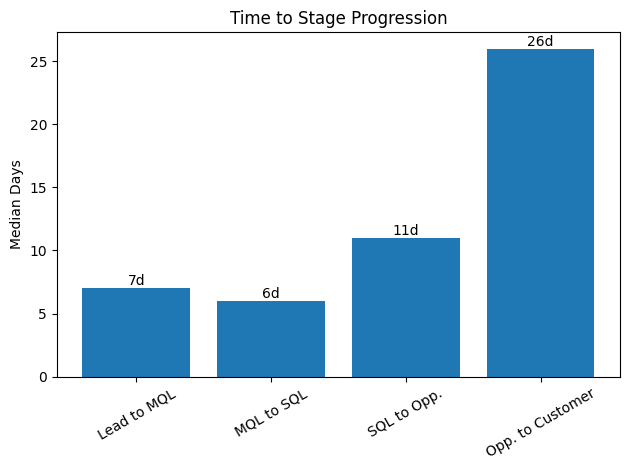

In [0]:
%python
df = spark.sql("""
with stage_times as (
  select
    datediff(became_mql_at, became_lead_at) as lead_to_mql,
    datediff(became_sql_at, became_mql_at) as mql_to_sql,
    datediff(became_opportunity_at, became_sql_at) as sql_to_opportunity,
    datediff(became_customer_at, became_opportunity_at) as opportunity_to_customer
  from crm_clean_contacts
)

select
  percentile_approx(lead_to_mql, 0.5) as lead_to_mql,
  percentile_approx(mql_to_sql, 0.5) as mql_to_sql,
  percentile_approx(sql_to_opportunity, 0.5) as sql_to_opportunity,
  percentile_approx(opportunity_to_customer, 0.5) as opportunity_to_customer
from stage_times
""").toPandas()

stages = ["Lead to MQL", "MQL to SQL", "SQL to Opp.", "Opp. to Customer"]
values = df.iloc[0].values

plt.figure()
plt.bar(stages, values)

plt.xticks(rotation=30)
plt.ylabel("Median Days")
plt.title("Time to Stage Progression")

for i, v in enumerate(values):
    plt.text(i, v, f"{int(v)}d", ha='center', va='bottom')

plt.tight_layout()

###Identifying Drop-offs and Bottlenecks

- Early-stage progression (Lead to SQL) is both fast and consistent, with ~50% conversion rates and short time-to-stage, indicating an efficient qualification process.
- SQL to Opportunity shows moderate friction, with slightly longer progression times but stable conversion rates.
- Opportunity to Customer represents the primary bottleneck in the funnel, combining the lowest conversion rate (~29%) with the longest time-to-stage (26 days).
- This indicates that late-stage deal execution, rather than lead generation or qualification, is the primary constraint on overall funnel performance.

###Funnel Segmentation

####Conversion by Lead Source

In [0]:
with base as (
  select
    lead_source,
    became_lead_at,
    became_mql_at,
    became_sql_at,
    became_opportunity_at,
    became_customer_at
  from crm_clean_contacts
),

aggregate as (
  select
    lead_source,
    sum(case when became_lead_at is not null then 1 else 0 end) as leads,
    sum(case when became_mql_at is not null then 1 else 0 end) as mqls,
    sum(case when became_sql_at is not null then 1 else 0 end) as sqls,
    sum(case when became_opportunity_at is not null then 1 else 0 end) as opportunities,
    sum(case when became_customer_at is not null then 1 else 0 end) as customers
  from base
  group by lead_source
)

select
  lead_source,
  round(mqls * 100.0 / leads, 2) as lead_to_mql,
  round(sqls * 100.0 / mqls, 2) as mql_to_sql,
  round(opportunities * 100.0 / sqls, 2) as sql_to_opportunity,
  round(customers * 100.0 / opportunities, 2) as opportunity_to_customer,
  round(customers * 100.0 / leads, 2) as lead_to_customer
from aggregate
order by lead_to_customer desc

lead_source,lead_to_mql,mql_to_sql,sql_to_opportunity,opportunity_to_customer,lead_to_customer
Outbound,47.19,51.49,53.99,33.16,4.35
Partner,53.88,52.00,46.92,31.15,4.09
Referral,47.75,43.53,51.35,36.84,3.93
Organic,48.78,47.50,48.87,33.85,3.83
Event,46.43,50.77,46.97,32.26,3.57
Paid Search,48.05,47.04,50.33,30.26,3.44
Content,48.53,47.80,54.02,22.70,2.84
Webinar,50.00,51.89,47.92,22.83,2.84


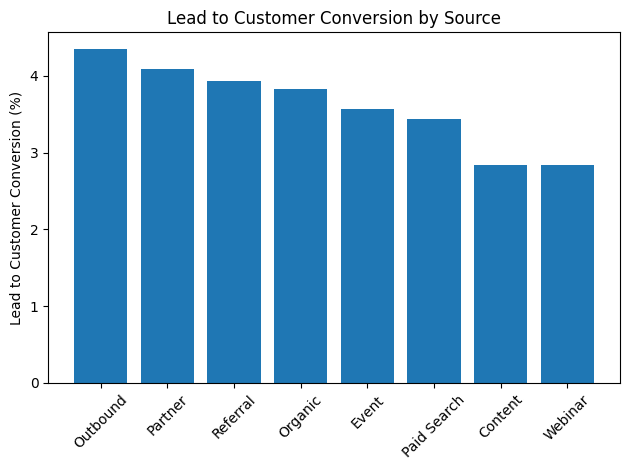

In [0]:
%python
df = spark.sql("""
with base as (
  select
    lead_source,
    became_lead_at,
    became_customer_at
  from crm_clean_contacts
),

agg as (
  select
    lead_source,
    sum(case when became_lead_at is not null then 1 else 0 end) as leads,
    sum(case when became_customer_at is not null then 1 else 0 end) as customers
  from base
  group by lead_source
)

select
  lead_source,
  leads,
  customers,
  round(customers * 100.0 / leads, 2) as lead_to_customer_conversion
from agg
where leads > 50
order by lead_to_customer_conversion desc 
""").toPandas()

plt.figure()
plt.bar(df["lead_source"], df["lead_to_customer_conversion"])

plt.xticks(rotation=45)
plt.ylabel("Lead to Customer Conversion (%)")
plt.title("Lead to Customer Conversion by Source")

plt.tight_layout()

- Outbound and Partner sources show the highest end-to-end conversion, indicating strong lead quality and alignment with high-intent prospects.
- Referral performs best at the late stage (Opportunity to Customer), but slightly lower early-stage conversion reduces overall performance.
- Organic, Event, and Paid Search show steady but middle-tier performance across all stages, suggesting broadly effective but less specialized acquisition channels.
- Content and Webinar sources show the lowest end-to-end conversion, driven primarily by significantly weaker late-stage performance, indicating lower purchase intent or less qualified leads.
- Variation across sources highlights that both early-stage lead quality and late-stage conversion effectiveness contribute to overall funnel performance, with some channels excelling in one stage but underperforming in others.

####Conversion by Job Title Category

In [0]:
with base as (
  select
    job_title_category_clean,
    became_lead_at,
    became_mql_at,
    became_sql_at,
    became_opportunity_at,
    became_customer_at
  from crm_clean_contacts
),

aggregate as (
  select
    job_title_category_clean,
    sum(case when became_lead_at is not null then 1 else 0 end) as leads,
    sum(case when became_mql_at is not null then 1 else 0 end) as mqls,
    sum(case when became_sql_at is not null then 1 else 0 end) as sqls,
    sum(case when became_opportunity_at is not null then 1 else 0 end) as opportunities,
    sum(case when became_customer_at is not null then 1 else 0 end) as customers
  from base
  group by job_title_category_clean
)

select
  job_title_category_clean,
  round(mqls * 100.0 / leads, 2) as lead_to_mql,
  round(sqls * 100.0 / mqls, 2) as mql_to_sql,
  round(opportunities * 100.0 / sqls, 2) as sql_to_opportunity,
  round(customers * 100.0 / leads, 2) as lead_to_customer_conversion
from aggregate
where leads > 50
order by lead_to_customer_conversion desc

job_title_category_clean,lead_to_mql,mql_to_sql,sql_to_opportunity,lead_to_customer_conversion
Operations,49.80,51.84,55.12,4.67
Executive,50.27,49.18,54.98,3.92
Unknown,46.52,50.00,45.67,3.85
Energy,46.32,49.55,50.00,3.68
Sales/Marketing,50.23,46.85,53.85,3.62
Legal,47.19,44.50,51.55,3.46
Finance,49.53,49.59,53.30,3.10
RevOps,55.21,48.89,47.73,3.07
Other,48.24,52.31,46.05,2.93


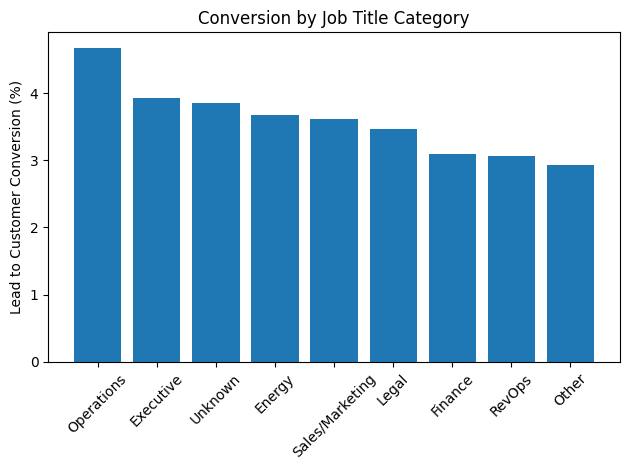

In [0]:
%python
import matplotlib.pyplot as plt

df = spark.sql("""
with base as (
  select
    job_title_category_clean,
    became_lead_at,
    became_mql_at,
    became_sql_at,
    became_opportunity_at,
    became_customer_at
  from crm_clean_contacts
),

aggregate as (
  select
    job_title_category_clean,
    sum(case when became_lead_at is not null then 1 else 0 end) as leads,
    sum(case when became_mql_at is not null then 1 else 0 end) as mqls,
    sum(case when became_sql_at is not null then 1 else 0 end) as sqls,
    sum(case when became_opportunity_at is not null then 1 else 0 end) as opportunities,
    sum(case when became_customer_at is not null then 1 else 0 end) as customers
  from base
  group by job_title_category_clean
)

select
  job_title_category_clean,
  round(mqls * 100.0 / leads, 2) as lead_to_mql,
  round(sqls * 100.0 / mqls, 2) as mql_to_sql,
  round(opportunities * 100.0 / sqls, 2) as sql_to_opportunity,
  round(customers * 100.0 / leads, 2) as lead_to_customer_conversion
from aggregate
where leads > 50
order by lead_to_customer_conversion desc
""").toPandas()

plt.figure()
plt.bar(df["job_title_category_clean"], df["lead_to_customer_conversion"])

plt.xticks(rotation=45)
plt.ylabel("Lead to Customer Conversion (%)")
plt.title("Conversion by Job Title Category")

plt.tight_layout()

- Operations roles show the highest end-to-end conversion, suggesting strong alignment with product value and buying intent.
- Executive and core business roles (Sales/Marketing, Energy) perform consistently just below top performers, indicating broad applicability across decision-makers.
- Finance and RevOps roles show lower conversion rates, suggesting these roles may be less directly involved in purchasing decisions or require different messaging.
- The “Other” category performs the worst, reinforcing that unclear or non-core roles have weaker conversion outcomes.